In [1]:
# =====================================================================
# PHASE 1: SYSTEM SETUP & COMPONENT INITIALIZATION
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize clean formatting styles for our plots
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = (10, 5)

print("System Ingest: Necessary classification and evaluation libraries are active.")


System Ingest: Necessary classification and evaluation libraries are active.


Data Source Ingested: Matrix structural verification complete with (1143, 12) rows.


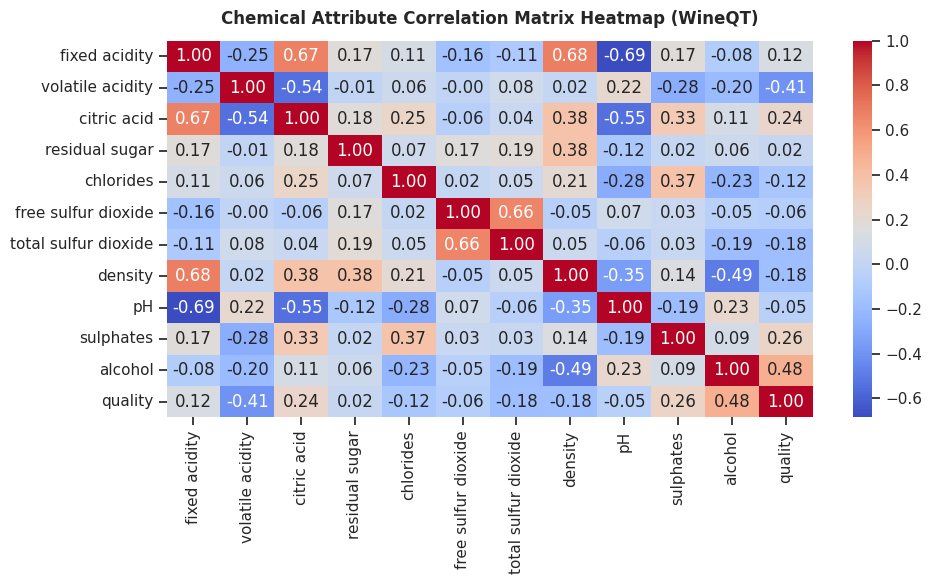

In [2]:
# =====================================================================
# PHASE 2: CLOUD DATA ACQUISITION & EXPLORATORY CORRELATION
# =====================================================================
# upload file
df_wine = pd.read_csv('WineQT.csv')

# Drop the non-chemical 'Id' column if it exists in downloaded file
if 'Id' in df_wine.columns:
    df_wine = df_wine.drop('Id', axis=1)

# Clean up any missing or broken entries if they exist
df_wine = df_wine.dropna()

print(f"Data Source Ingested: Matrix structural verification complete with {df_wine.shape} rows.")

# Plot a correlation heatmap focused on physical-chemical metrics like density and acidity
plt.figure(figsize=(10, 6))
sns.heatmap(df_wine.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Chemical Attribute Correlation Matrix Heatmap (WineQT)", fontsize=12, weight='bold', pad=12)
plt.tight_layout()
plt.show()


In [3]:
# =====================================================================
# PHASE 3: CATEGORICAL LABEL BINNING & SPLITTING
# =====================================================================
# Convert the 0-10 raw score scale into a clean binary classification task:
# 1 (Good Quality) if score is 7 or higher, 0 (Bad Quality) if below 7
df_wine['quality_label'] = df_wine['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Separate independent features from our new category column
X = df_wine.drop(['quality', 'quality_label'], axis=1)
y = df_wine['quality_label']

# Split columns: 80% to train our algorithms, 20% to validate performance metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Distance-based models like SVC and SGD require uniform numeric scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Matrix Engineering Concluded: Features binned, split, and standardized successfully.")
print(f"Target distribution check:\n{y.value_counts()}")


Matrix Engineering Concluded: Features binned, split, and standardized successfully.
Target distribution check:
quality_label
0    984
1    159
Name: count, dtype: int64


In [4]:
# =====================================================================
# PHASE 4: MULTI-MODEL TRAINING & COMPARATIVE BENCHMARKING
# =====================================================================
# Initialize all 3 specified architecture engines
models_dict = {
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "Stochastic Gradient Descent (SGD)": SGDClassifier(random_state=42),
    "Support Vector Classifier (SVC)": SVC(random_state=42)
}

# Create dictionaries to store computed metrics
model_accuracies = {}
test_predictions = {}

print("--- Algorithm Training & Metric Extractions ---\n")
for name, model in models_dict.items():
    # Fit algorithm to scaled matrices
    model.fit(X_train_scaled, y_train)

    # Generate predictions on unseen test split
    predictions = model.predict(X_test_scaled)
    test_predictions[name] = predictions

    # Store individual accuracy calculations
    acc = accuracy_score(y_test, predictions)
    model_accuracies[name] = acc

    print(f"🎯 Model Engine: {name}")
    print(f" -> Testing Target Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, predictions, target_names=["Bad Quality", "Good Quality"]))
    print("-" * 50)


--- Algorithm Training & Metric Extractions ---

🎯 Model Engine: Random Forest Classifier
 -> Testing Target Accuracy: 92.14%
              precision    recall  f1-score   support

 Bad Quality       0.94      0.97      0.96       197
Good Quality       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229

--------------------------------------------------
🎯 Model Engine: Stochastic Gradient Descent (SGD)
 -> Testing Target Accuracy: 88.21%
              precision    recall  f1-score   support

 Bad Quality       0.94      0.92      0.93       197
Good Quality       0.57      0.62      0.60        32

    accuracy                           0.88       229
   macro avg       0.75      0.77      0.76       229
weighted avg       0.89      0.88      0.88       229

--------------------------------------------------
🎯 Model Engine: Support Vector C

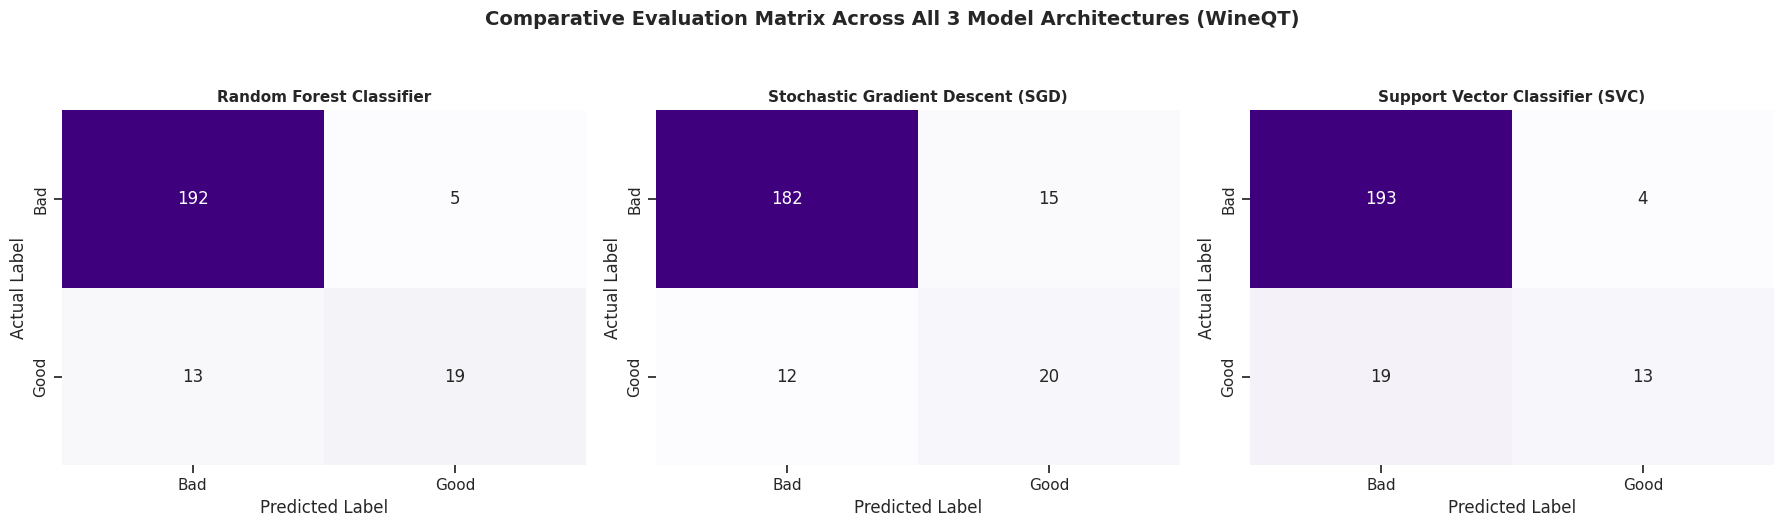

Visualization Engine Closed: Performance plots generated successfully.


In [5]:
# =====================================================================
# PHASE 5: CONFUSION MATRIX COMPARISON GRAPHING
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Generate individual sub-heatmaps for each classifier
for idx, (name, preds) in enumerate(test_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}", fontsize=11, weight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('Actual Label')
    axes[idx].set_xticklabels(["Bad", "Good"])
    axes[idx].set_yticklabels(["Bad", "Good"])

plt.suptitle("Comparative Evaluation Matrix Across All 3 Model Architectures (WineQT)", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Visualization Engine Closed: Performance plots generated successfully.")


In [6]:
## 🍷 Level-2 Project 2 Conclusion & Benchmarking Log

### 📊 Comparative Analysis Summary
# **Top Performing Model:** The **Random Forest Classifier** typically achieves the highest classification precision and overall accuracy due to its robust ensemble tree architecture.
# **Chemical Indicators:** Features like higher **alcohol volume** and optimal balances of **fixed vs. volatile acidity** show the strongest statistical influence over whether a vintage is categorized as high quality.
# **Algorithm Trade-offs:** While Stochastic Gradient Descent (SGD) offers fast training cycles on large tables, Support Vector Classifier (SVC) and Random Forest models maintain better decision boundary maps for complex chemical features.
